# Experiment: Pet Triage Final Report

Objective:
- Reproduce the main descriptive and predictive results using the code and saved artifacts in this repo.
- Show the modeling progression from a simple bag-of-words urgency baseline to the final BioBERT-based multitask model.
- Document how the text and image branches fit together in the final multimodal triage system.
- Save clean figures and summary metrics that can be reused in the executive summary.

Success criteria:
- We can explain what each major training and app file does.
- We fit a transparent lexical baseline on the triage data.
- We evaluate the saved `triage_multitask_model_10k.pt` checkpoint on the held-out 10k test split.
- We capture publication-ready figures for EDA and evaluation.


## Plan

- Hypothesis 1: a lexical bag-of-words baseline will learn obvious urgency phrases, but it will be weaker on nuanced clinical wording and class boundaries.
- Hypothesis 2: the final BioBERT multitask model should outperform the baseline because it starts from biomedical language pretraining and shares information between urgency classification and named-entity recognition (NER).
- Hypothesis 3: the image branch is valuable for breed prediction, but the strongest measured accuracy jump in this repo comes from the text pipeline upgrade.
- Metrics to record: urgency accuracy, macro F1, weighted F1, confusion matrices, token-level NER accuracy, selected NER class F1, and image/text dataset summary counts.

Report language note:
- In the written report I use **BioBreed extension** as shorthand for the final upgraded system: BioBERT for clinical text plus the breed-prediction image branch.
- In the actual codebase the relevant files are `nlp_gpu.py` (BioBERT multitask model) and `image_processing_gpu.py` (EfficientNetB3 breed classifier). There is no separate pretrained model literally named `BioBreed`.


In [1]:
from __future__ import annotations

import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the notebook working directory.")


ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = ROOT / "output" / "jupyter-notebook"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRIAGE_2500_PATH = ROOT / "triage_dataset_2500_clean.jsonl"
TRIAGE_10K_PATH = ROOT / "triage_dataset_10k_clean.jsonl"
IMAGE_ROOT = ROOT / "dog_breed"
BIOBERT_CHECKPOINT = ROOT / "triage_multitask_model_10k.pt"

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
MAX_LEN = 256
BATCH_SIZE = 16
DEVICE = torch.device("cpu")

URGENCY_NAMES = {
    1: "Red / Immediate",
    2: "Orange / Emergent",
    3: "Yellow / Urgent",
    4: "Green / Semi-Urgent",
    5: "Blue / Non-Urgent",
}
URGENCY_LEVELS = [1, 2, 3, 4, 5]

ENTITY_TYPES = [
    "AGE",
    "BREED",
    "DURATION",
    "EXPOSURE",
    "MEDICATION",
    "PRE_EXISTING",
    "SEX_STATUS",
    "SYMPTOM",
    "TOXIN",
]

print(
    {
        "seed": SEED,
        "device": str(DEVICE),
        "output_dir": str(OUTPUT_DIR),
        "fig_dir": str(FIG_DIR),
    }
)


/Users/zhucanran/611_final_project_deeplearning-1/.report-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'seed': 42, 'device': 'cpu', 'output_dir': '/Users/zhucanran/611_final_project_deeplearning-1/output/jupyter-notebook', 'fig_dir': '/Users/zhucanran/611_final_project_deeplearning-1/output/jupyter-notebook/figures'}


## Repository walkthrough

The final project is easier to understand if we map each file to one clear role:


In [2]:
repo_map = pd.DataFrame(
    [
        {
            "file": "README.md",
            "role": "Project narrative and final reported metrics",
        },
        {
            "file": "embedding.py",
            "role": "Early text baselines using bag-of-words and embedding models",
        },
        {
            "file": "text_models_bow_and_embedding.py",
            "role": "Alternative Keras baseline implementations for urgency prediction",
        },
        {
            "file": "MultimodalFusionLayer.py",
            "role": "Original fusion prototype combining text and image features",
        },
        {
            "file": "image_processing_gpu.py",
            "role": "EfficientNetB3 dog breed training script",
        },
        {
            "file": "nlp_gpu.py",
            "role": "Final BioBERT multitask trainer for urgency plus NER",
        },
        {
            "file": "app.py",
            "role": "Original Streamlit app for the fusion prototype",
        },
        {
            "file": "app_gpu.py",
            "role": "Final Streamlit app using separate image and text models",
        },
    ]
)
display(repo_map)


,file,role
0,README.md,Project narrative and final reported metrics
1,embedding.py,Early text baselines using bag-of-words and em...
2,text_models_bow_and_embedding.py,Alternative Keras baseline implementations for...
3,MultimodalFusionLayer.py,Original fusion prototype combining text and i...
4,image_processing_gpu.py,EfficientNetB3 dog breed training script
5,nlp_gpu.py,Final BioBERT multitask trainer for urgency pl...
6,app.py,Original Streamlit app for the fusion prototype
7,app_gpu.py,Final Streamlit app using separate image and t...


## Load the local datasets

We keep the notebook honest by loading the exact files that are stored in the repo:
- `triage_dataset_2500_clean.jsonl` for the smaller earlier text experiments.
- `triage_dataset_10k_clean.jsonl` for the final BioBERT training pipeline.
- `dog_breed/` for the image branch split into train, validation, and test folders.


In [3]:
def load_triage_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    df = pd.DataFrame(rows)
    df["text_len_chars"] = df["text"].str.len()
    df["text_len_words"] = df["text"].str.split().str.len()
    df["entity_count"] = df["entities"].apply(len)
    return df


def count_images_in_split(split_dir: Path) -> int:
    return sum(
        1
        for ext in ("*.jpg", "*.jpeg", "*.png")
        for _ in split_dir.rglob(ext)
    )


triage_2500 = load_triage_jsonl(TRIAGE_2500_PATH)
triage_10k = load_triage_jsonl(TRIAGE_10K_PATH)

image_split_summary = []
for split in ["train", "validation", "test"]:
    split_dir = IMAGE_ROOT / split
    class_dirs = [d for d in split_dir.iterdir() if d.is_dir()]
    image_split_summary.append(
        {
            "split": split,
            "classes": len(class_dirs),
            "images": count_images_in_split(split_dir),
        }
    )

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": "triage_dataset_2500_clean.jsonl",
            "samples": len(triage_2500),
            "mean_words": round(triage_2500["text_len_words"].mean(), 1),
            "mean_entities": round(triage_2500["entity_count"].mean(), 2),
        },
        {
            "dataset": "triage_dataset_10k_clean.jsonl",
            "samples": len(triage_10k),
            "mean_words": round(triage_10k["text_len_words"].mean(), 1),
            "mean_entities": round(triage_10k["entity_count"].mean(), 2),
        },
    ]
)

display(dataset_overview)
display(pd.DataFrame(image_split_summary))


,dataset,samples,mean_words,mean_entities
0,triage_dataset_2500_clean.jsonl,2499,85.6,7.57
1,triage_dataset_10k_clean.jsonl,9984,86.8,8.60


,split,classes,images
0,train,120,14355
1,validation,120,4115
2,test,120,2110


## Descriptive analysis

These plots answer four simple questions:
1. How are urgency levels distributed in the 2.5k and 10k text datasets?
2. How long are the owner-written case descriptions?
3. Which entity labels appear most often?
4. How large is the image branch across train, validation, and test?


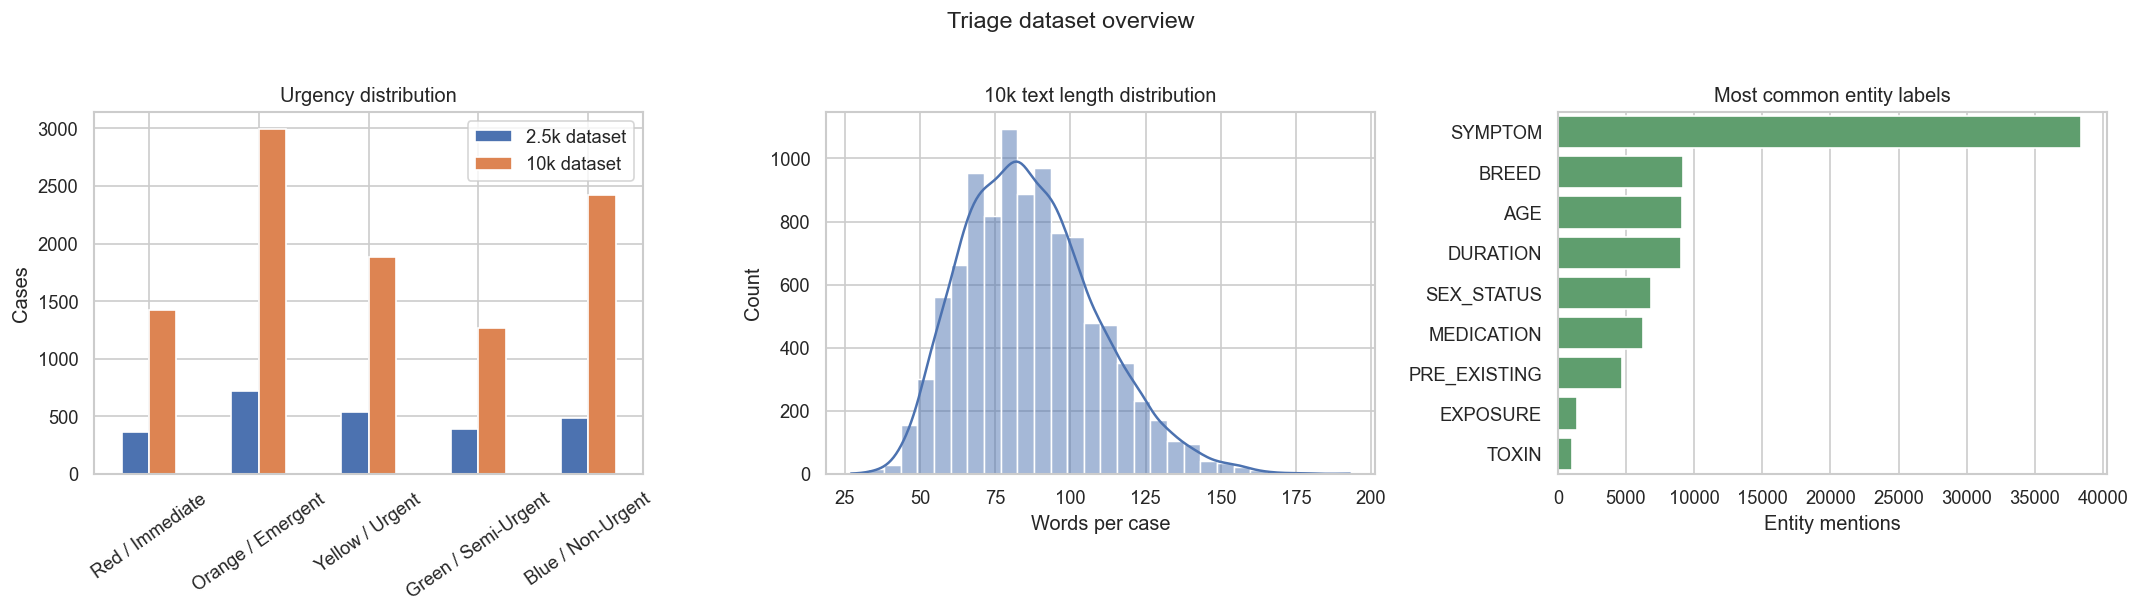

In [4]:
urgency_2500 = (
    triage_2500["urgency_level"]
    .value_counts()
    .sort_index()
    .rename(index=URGENCY_NAMES)
)
urgency_10k = (
    triage_10k["urgency_level"]
    .value_counts()
    .sort_index()
    .rename(index=URGENCY_NAMES)
)

entity_counter = Counter()
for entities in triage_10k["entities"]:
    for ent in entities:
        entity_counter[ent["label"]] += 1
entity_df = (
    pd.DataFrame(
        {"entity_type": list(entity_counter.keys()), "count": list(entity_counter.values())}
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

urgency_plot_df = pd.DataFrame(
    {
        "2.5k dataset": urgency_2500,
        "10k dataset": urgency_10k,
    }
)
urgency_plot_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("Urgency distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cases")
axes[0].tick_params(axis="x", rotation=35)

sns.histplot(triage_10k["text_len_words"], bins=30, kde=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("10k text length distribution")
axes[1].set_xlabel("Words per case")

sns.barplot(
    data=entity_df.head(9),
    x="count",
    y="entity_type",
    ax=axes[2],
    color="#55A868",
)
axes[2].set_title("Most common entity labels")
axes[2].set_xlabel("Entity mentions")
axes[2].set_ylabel("")

fig.suptitle("Triage dataset overview", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "triage_eda_overview.png", bbox_inches="tight", dpi=200)
plt.show()


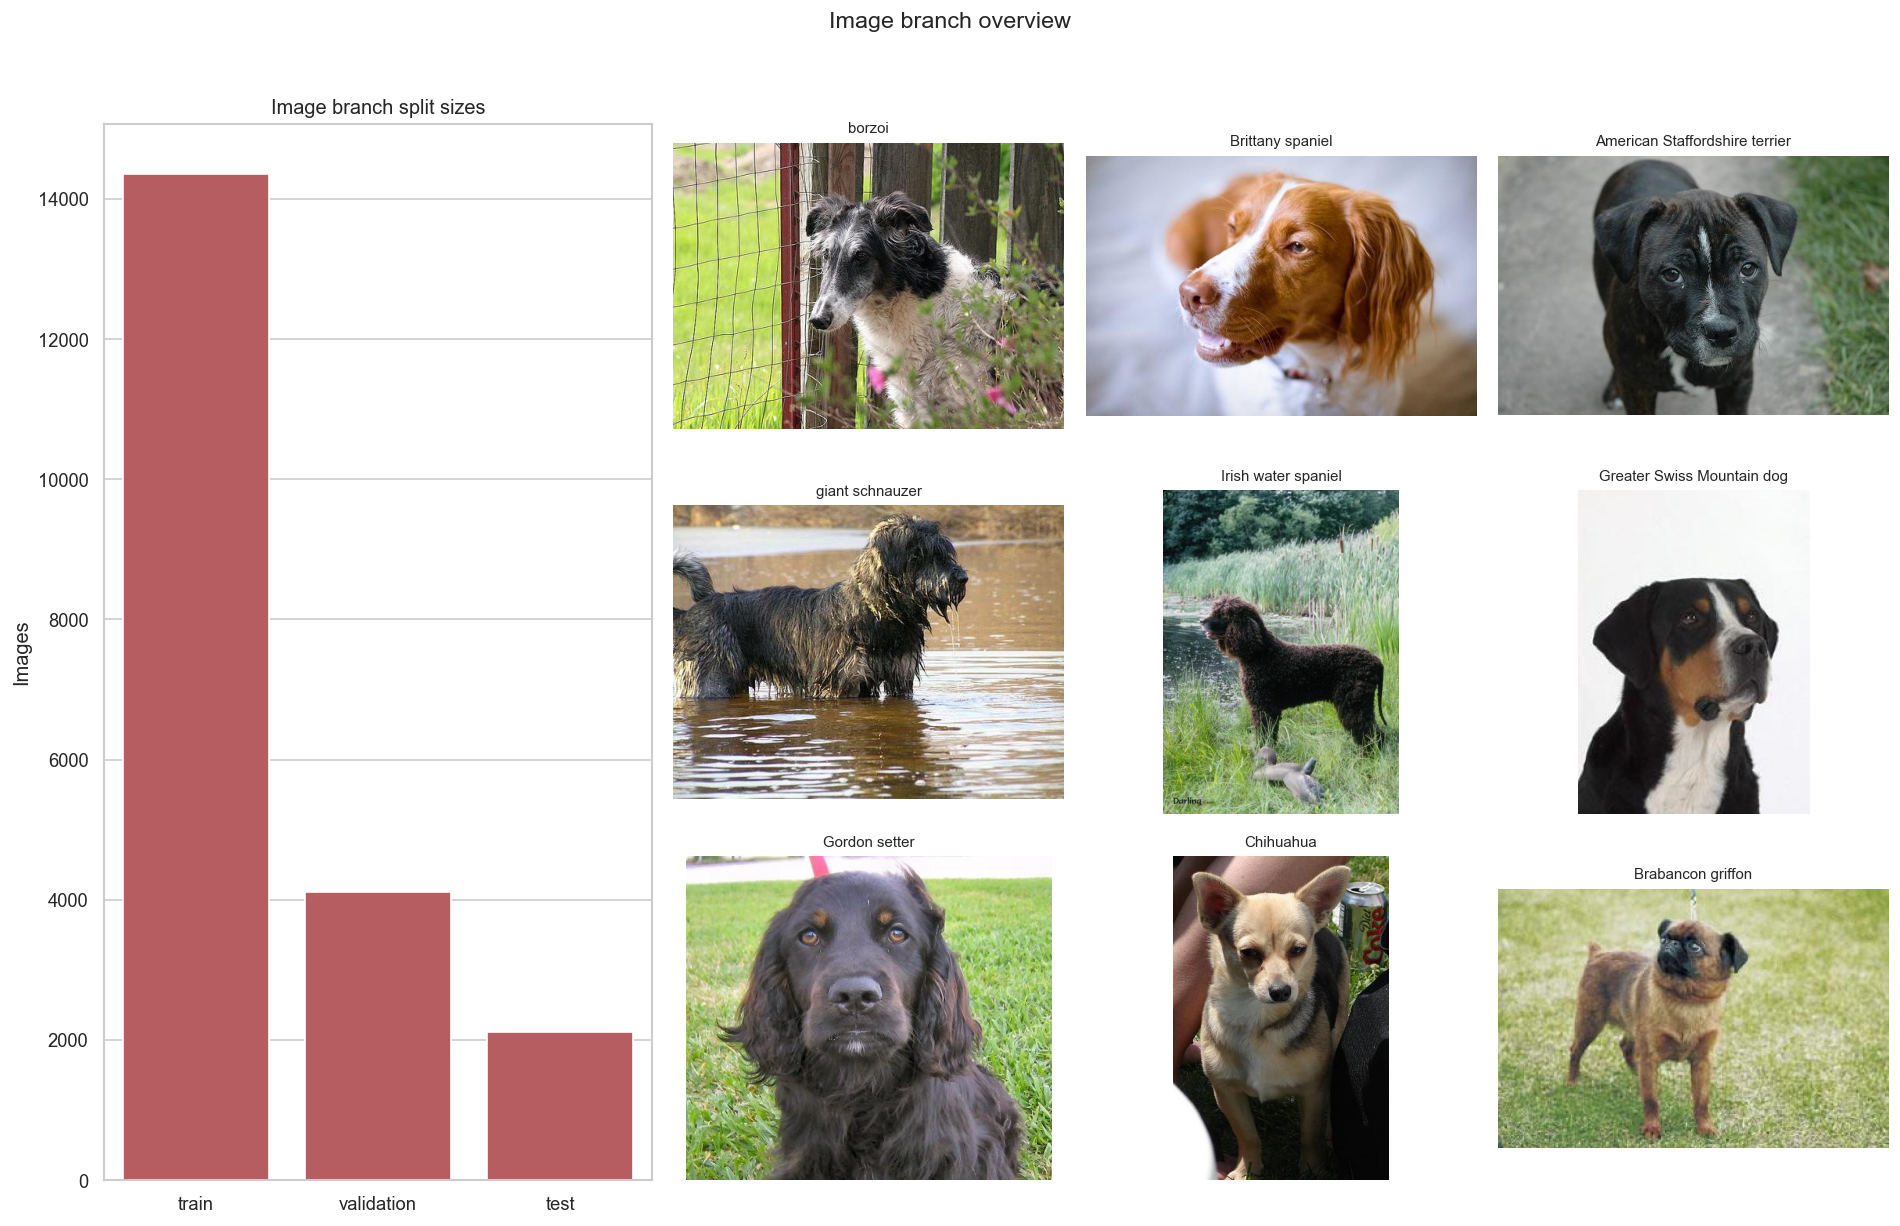

In [5]:
image_split_df = pd.DataFrame(image_split_summary)

train_breeds = sorted([d for d in (IMAGE_ROOT / "train").iterdir() if d.is_dir()])
sample_breeds = random.sample(train_breeds, 9)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 4, width_ratios=[1.4, 1, 1, 1])

ax_bar = fig.add_subplot(gs[:, 0])
sns.barplot(data=image_split_df, x="split", y="images", ax=ax_bar, color="#C44E52")
ax_bar.set_title("Image branch split sizes")
ax_bar.set_xlabel("")
ax_bar.set_ylabel("Images")

for i, breed_dir in enumerate(sample_breeds):
    row = i // 3
    col = i % 3 + 1
    ax = fig.add_subplot(gs[row, col])
    image_path = sorted(
        list(breed_dir.glob("*.jpg")) + list(breed_dir.glob("*.jpeg")) + list(breed_dir.glob("*.png"))
    )[0]
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(breed_dir.name.replace("_", " "), fontsize=9)
    ax.axis("off")

fig.suptitle("Image branch overview", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "image_branch_overview.png", bbox_inches="tight", dpi=200)
plt.show()


## Baseline predictive model

The repo already contains Keras bag-of-words and embedding baselines in `embedding.py` and `text_models_bow_and_embedding.py`.
For a fast, fully reproducible notebook baseline, I fit a linear bag-of-words classifier with binary unigram and bigram features.

Why this is a fair baseline:
- It still represents the same core idea as the repo's lexical baseline: predictions come directly from observed words and phrases.
- It is transparent enough to explain in class.
- It trains quickly on both the 2.5k and 10k datasets, which lets us isolate the effect of more data before we move to BioBERT.


In [6]:
def repo_style_split(df: pd.DataFrame):
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def fit_bow_baseline(df: pd.DataFrame, dataset_name: str):
    train_df, val_df, test_df = repo_style_split(df)

    vectorizer = CountVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        binary=True,
        min_df=2,
        lowercase=True,
    )
    X_train = vectorizer.fit_transform(train_df["text"])
    X_val = vectorizer.transform(val_df["text"])
    X_test = vectorizer.transform(test_df["text"])

    clf = LogisticRegression(max_iter=2_000)
    clf.fit(X_train, train_df["urgency_level"])

    val_pred = clf.predict(X_val)
    test_pred = clf.predict(X_test)

    return {
        "dataset": dataset_name,
        "vectorizer": vectorizer,
        "model": clf,
        "train_size": len(train_df),
        "val_size": len(val_df),
        "test_size": len(test_df),
        "val_accuracy": accuracy_score(val_df["urgency_level"], val_pred),
        "test_accuracy": accuracy_score(test_df["urgency_level"], test_pred),
        "test_macro_f1": f1_score(test_df["urgency_level"], test_pred, average="macro"),
        "test_weighted_f1": f1_score(
            test_df["urgency_level"], test_pred, average="weighted"
        ),
        "y_true": test_df["urgency_level"].to_numpy(),
        "y_pred": test_pred,
    }


baseline_2500 = fit_bow_baseline(triage_2500, "BoW baseline on 2.5k")
baseline_10k = fit_bow_baseline(triage_10k, "BoW baseline on 10k")

baseline_results_df = pd.DataFrame(
    [
        {
            "model": baseline_2500["dataset"],
            "test_accuracy": baseline_2500["test_accuracy"],
            "test_macro_f1": baseline_2500["test_macro_f1"],
            "test_weighted_f1": baseline_2500["test_weighted_f1"],
        },
        {
            "model": baseline_10k["dataset"],
            "test_accuracy": baseline_10k["test_accuracy"],
            "test_macro_f1": baseline_10k["test_macro_f1"],
            "test_weighted_f1": baseline_10k["test_weighted_f1"],
        },
    ]
).round(4)

display(baseline_results_df)


,model,test_accuracy,test_macro_f1,test_weighted_f1
0,BoW baseline on 2.5k,0.7360,0.7078,0.7367
1,BoW baseline on 10k,0.7908,0.7772,0.7886


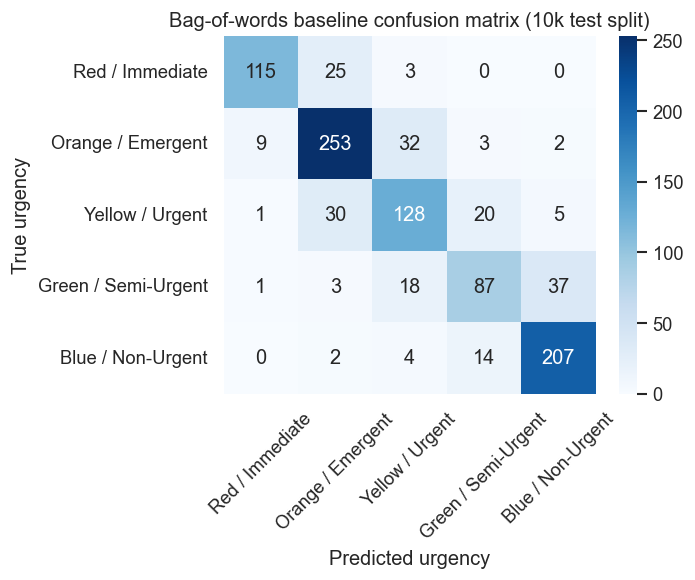

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(
    baseline_10k["y_true"],
    baseline_10k["y_pred"],
    labels=URGENCY_LEVELS,
)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
    yticklabels=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
)
ax.set_title("Bag-of-words baseline confusion matrix (10k test split)")
ax.set_xlabel("Predicted urgency")
ax.set_ylabel("True urgency")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "bow_baseline_confusion_matrix.png", bbox_inches="tight", dpi=200)
plt.show()


## Improved predictive model: BioBERT multitask urgency plus NER

The final model in `nlp_gpu.py` uses:
- `dmis-lab/biobert-base-cased-v1.2` as the language backbone,
- one classification head for the five urgency levels,
- one token-level head for BIO-tagged named-entity recognition,
- a combined loss of `urgency_loss + 0.3 * ner_loss`.

For reproducibility, I evaluate the saved checkpoint `triage_multitask_model_10k.pt` on the same repo-style 80/10/10 split used by the training script.


In [8]:
ENTITY_TYPES = [
    "AGE",
    "BREED",
    "DURATION",
    "EXPOSURE",
    "MEDICATION",
    "PRE_EXISTING",
    "SEX_STATUS",
    "SYMPTOM",
    "TOXIN",
]
NER_LABELS = ["O"]
for entity_type in ENTITY_TYPES:
    NER_LABELS.append(f"B-{entity_type}")
    NER_LABELS.append(f"I-{entity_type}")
NER_LABEL2ID = {label: idx for idx, label in enumerate(NER_LABELS)}
NUM_NER_LABELS = len(NER_LABELS)
NUM_URGENCY_CLASSES = 5


def load_repo_samples(path: Path):
    samples = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            samples.append(
                {
                    "text": row["text"],
                    "urgency": row["urgency_level"] - 1,
                    "entities": row.get("entities", []),
                }
            )
    return samples


def align_entities_to_tokens(text, entities, tokenizer, max_len):
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_offsets_mapping=True,
        return_tensors="pt",
    )

    offsets = encoding["offset_mapping"][0].tolist()
    ner_labels = [-100] * max_len

    for i, (start, end) in enumerate(offsets):
        if start == 0 and end == 0:
            continue
        ner_labels[i] = NER_LABEL2ID["O"]

    text_lower = text.lower()
    for ent in entities:
        phrase = ent["phrase"]
        label = ent["label"]
        if label not in ENTITY_TYPES:
            continue

        char_start = text_lower.find(phrase.lower())
        if char_start == -1:
            continue
        char_end = char_start + len(phrase)

        first = True
        for i, (tok_start, tok_end) in enumerate(offsets):
            if tok_start == tok_end == 0:
                continue
            if tok_start >= char_start and tok_end <= char_end:
                tag = f"B-{label}" if first else f"I-{label}"
                ner_labels[i] = NER_LABEL2ID[tag]
                first = False

    encoding.pop("offset_mapping")
    return encoding, ner_labels


class TriageDataset(Dataset):
    def __init__(self, samples, tokenizer, max_len):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        encoding, ner_labels = align_entities_to_tokens(
            sample["text"], sample["entities"], self.tokenizer, self.max_len
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "urgency_label": torch.tensor(sample["urgency"], dtype=torch.long),
            "ner_labels": torch.tensor(ner_labels, dtype=torch.long),
        }


class TriageMultiTaskModel(nn.Module):
    def __init__(self, model_name, num_urgency_classes, num_ner_labels):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.urgency_head = nn.Linear(hidden_size, num_urgency_classes)
        self.ner_head = nn.Linear(hidden_size, num_ner_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        token_outputs = outputs.last_hidden_state
        urgency_logits = self.urgency_head(cls_output)
        ner_logits = self.ner_head(token_outputs)
        return urgency_logits, ner_logits


def evaluate_multitask_model(model, dataloader):
    model.eval()
    all_urgency_preds = []
    all_urgency_true = []
    all_ner_preds = []
    all_ner_true = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            urgency_labels = batch["urgency_label"].to(DEVICE)
            ner_labels = batch["ner_labels"].to(DEVICE)

            urgency_logits, ner_logits = model(input_ids, attention_mask)

            all_urgency_preds.extend(
                urgency_logits.argmax(dim=1).cpu().tolist()
            )
            all_urgency_true.extend(urgency_labels.cpu().tolist())

            ner_pred = ner_logits.argmax(dim=2).cpu()
            ner_true = ner_labels.cpu()
            for i in range(ner_true.size(0)):
                for j in range(ner_true.size(1)):
                    if ner_true[i, j] != -100:
                        all_ner_preds.append(ner_pred[i, j].item())
                        all_ner_true.append(ner_true[i, j].item())

    return {
        "urgency_true": np.array(all_urgency_true),
        "urgency_pred": np.array(all_urgency_preds),
        "ner_true": np.array(all_ner_true),
        "ner_pred": np.array(all_ner_preds),
    }


In [9]:
samples_10k = load_repo_samples(TRIAGE_10K_PATH)
train_samples, temp_samples = train_test_split(
    samples_10k, test_size=0.2, random_state=SEED
)
val_samples, test_samples = train_test_split(
    temp_samples, test_size=0.5, random_state=SEED
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
test_dataset = TriageDataset(test_samples, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

biobert_model = TriageMultiTaskModel(
    MODEL_NAME, NUM_URGENCY_CLASSES, NUM_NER_LABELS
)
biobert_model.load_state_dict(
    torch.load(BIOBERT_CHECKPOINT, map_location=DEVICE, weights_only=True)
)
biobert_model.to(DEVICE)

biobert_eval = evaluate_multitask_model(biobert_model, test_loader)

urgency_true = biobert_eval["urgency_true"] + 1
urgency_pred = biobert_eval["urgency_pred"] + 1

biobert_summary = {
    "model": "BioBERT multitask model on 10k",
    "test_accuracy": accuracy_score(urgency_true, urgency_pred),
    "test_macro_f1": f1_score(urgency_true, urgency_pred, average="macro"),
    "test_weighted_f1": f1_score(urgency_true, urgency_pred, average="weighted"),
    "ner_token_accuracy": accuracy_score(
        biobert_eval["ner_true"], biobert_eval["ner_pred"]
    ),
}

urgency_report_df = pd.DataFrame(
    classification_report(
        urgency_true,
        urgency_pred,
        labels=URGENCY_LEVELS,
        target_names=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
        output_dict=True,
        zero_division=0,
    )
).T

ner_label_ids = sorted(
    set(biobert_eval["ner_true"].tolist()) | set(biobert_eval["ner_pred"].tolist())
)
ner_report_df = pd.DataFrame(
    classification_report(
        biobert_eval["ner_true"],
        biobert_eval["ner_pred"],
        labels=ner_label_ids,
        target_names=[NER_LABELS[i] for i in ner_label_ids],
        output_dict=True,
        zero_division=0,
    )
).T

display(pd.DataFrame([biobert_summary]).round(4))
display(urgency_report_df.loc[[URGENCY_NAMES[i] for i in URGENCY_LEVELS]].round(3))
display(
    ner_report_df.loc[
        [label for label in ["B-SYMPTOM", "I-SYMPTOM", "B-MEDICATION", "B-DURATION"] if label in ner_report_df.index]
    ].round(3)
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 48361.23it/s]


BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model,test_accuracy,test_macro_f1,test_weighted_f1,ner_token_accuracy
0,BioBERT multitask model on 10k,0.8408,0.8326,0.841,0.9252


,precision,recall,f1-score,support
Red / Immediate,0.928,0.902,0.915,143.0
Orange / Emergent,0.878,0.863,0.870,299.0
Yellow / Urgent,0.720,0.826,0.770,184.0
Green / Semi-Urgent,0.754,0.671,0.710,146.0
Blue / Non-Urgent,0.902,0.894,0.898,227.0


,precision,recall,f1-score,support
B-SYMPTOM,0.711,0.584,0.642,3892.0
I-SYMPTOM,0.759,0.808,0.783,11171.0
B-MEDICATION,0.970,0.997,0.983,612.0
B-DURATION,0.605,0.618,0.612,904.0


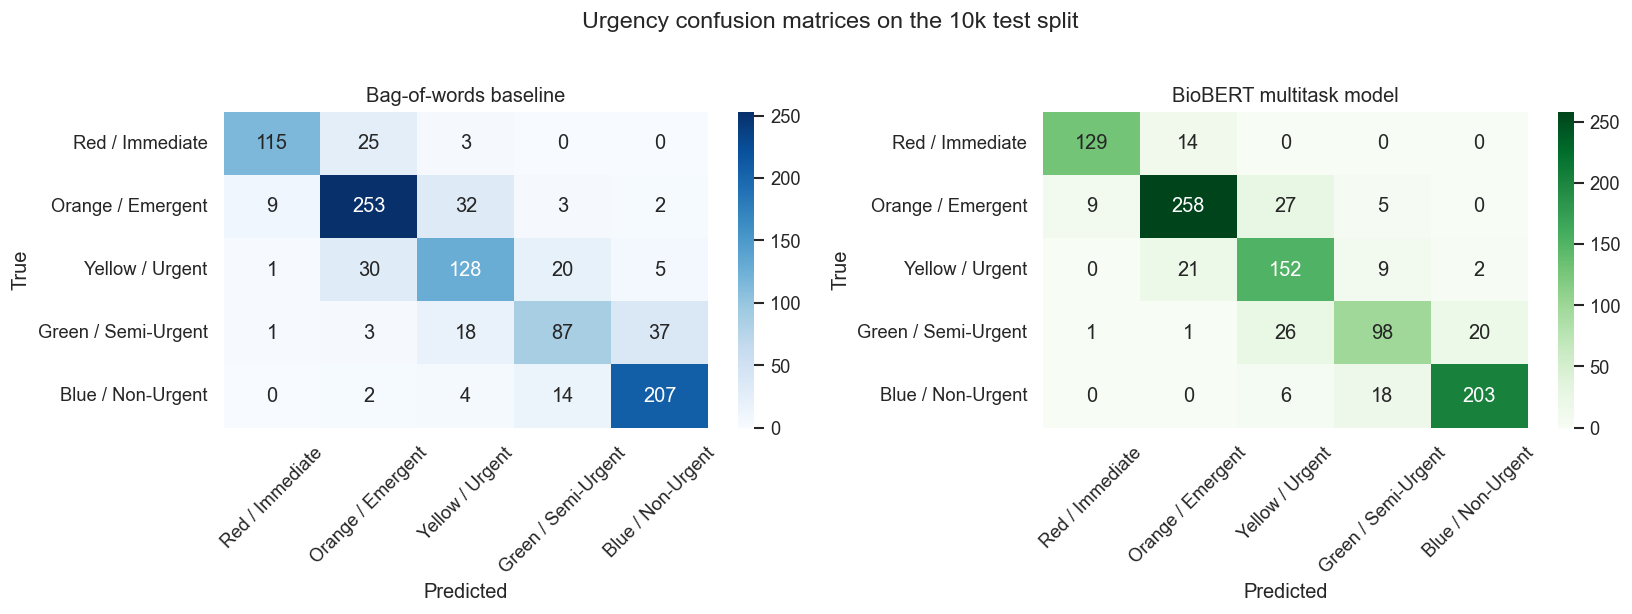

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_baseline = confusion_matrix(
    baseline_10k["y_true"],
    baseline_10k["y_pred"],
    labels=URGENCY_LEVELS,
)
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
    yticklabels=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
)
axes[0].set_title("Bag-of-words baseline")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

cm_biobert = confusion_matrix(
    urgency_true,
    urgency_pred,
    labels=URGENCY_LEVELS,
)
sns.heatmap(
    cm_biobert,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    xticklabels=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
    yticklabels=[URGENCY_NAMES[i] for i in URGENCY_LEVELS],
)
axes[1].set_title("BioBERT multitask model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

fig.suptitle("Urgency confusion matrices on the 10k test split", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "baseline_vs_biobert_confusion_matrix.png", bbox_inches="tight", dpi=200)
plt.show()


## Example predictions

A strong final report should not stop at aggregate metrics. The table below shows how the final model behaves on real held-out cases, including the extracted entities that make the urgency decision easier to interpret.


In [11]:
def predict_single_case(model, tokenizer, text: str):
    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    input_ids = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.no_grad():
        urgency_logits, ner_logits = model(input_ids, attention_mask)

    urgency_level = int(urgency_logits.argmax(dim=1).cpu().item()) + 1

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    ner_pred_ids = ner_logits.argmax(dim=2)[0].cpu().tolist()
    attention_values = attention_mask[0].cpu().tolist()

    entities = []
    current_label = None
    current_tokens = []

    for token, pred_id, mask in zip(tokens, ner_pred_ids, attention_values):
        if mask == 0 or token in ["[CLS]", "[SEP]", "[PAD]"]:
            if current_label:
                entities.append((current_label, tokenizer.convert_tokens_to_string(current_tokens)))
                current_label = None
                current_tokens = []
            continue

        tag = NER_LABELS[pred_id]
        if tag.startswith("B-"):
            if current_label:
                entities.append((current_label, tokenizer.convert_tokens_to_string(current_tokens)))
            current_label = tag[2:]
            current_tokens = [token]
        elif tag.startswith("I-") and current_label == tag[2:]:
            current_tokens.append(token)
        else:
            if current_label:
                entities.append((current_label, tokenizer.convert_tokens_to_string(current_tokens)))
                current_label = None
                current_tokens = []

    if current_label:
        entities.append((current_label, tokenizer.convert_tokens_to_string(current_tokens)))

    return urgency_level, entities


example_indices = [0, 25, 50]
example_rows = []
for idx in example_indices:
    sample = test_samples[idx]
    predicted_urgency, predicted_entities = predict_single_case(
        biobert_model, tokenizer, sample["text"]
    )
    gold_entities = ", ".join(
        f"{ent['label']}: {ent['phrase']}" for ent in sample["entities"][:5]
    )
    pred_entities = ", ".join(
        f"{label}: {phrase}" for label, phrase in predicted_entities[:5]
    )
    example_rows.append(
        {
            "case_excerpt": sample["text"][:140] + "...",
            "gold_urgency": URGENCY_NAMES[sample["urgency"] + 1],
            "predicted_urgency": URGENCY_NAMES[predicted_urgency],
            "gold_entities": gold_entities,
            "predicted_entities": pred_entities,
        }
    )

display(pd.DataFrame(example_rows))


,case_excerpt,gold_urgency,predicted_urgency,gold_entities,predicted_entities
0,I am contacting you regarding my six-month-old...,Blue / Non-Urgent,Blue / Non-Urgent,"AGE: six-month-old, BREED: Border Collie, SYMP...","AGE: six - month - old, BREED: border collie, ..."
1,"My dog, a nine-year-old neutered male West Hig...",Green / Semi-Urgent,Green / Semi-Urgent,"AGE: nine-year-old, SEX_STATUS: neutered male,...","AGE: nine - year - old, SEX_STATUS: neutered m..."
2,"hi, idk if im overreacting tbh but my cavvie, ...",Green / Semi-Urgent,Yellow / Urgent,"BREED: cavvie, AGE: 5, SYMPTOM: threw up, DURA...","BREED: cavvie, AGE: 5, DURATION: this, SYMPTOM..."


## Model development summary from the repo README

The notebook evaluation above uses the saved final checkpoint.
The plots below capture the staged improvements already documented in `README.md`, which are useful for the narrative part of the final report.


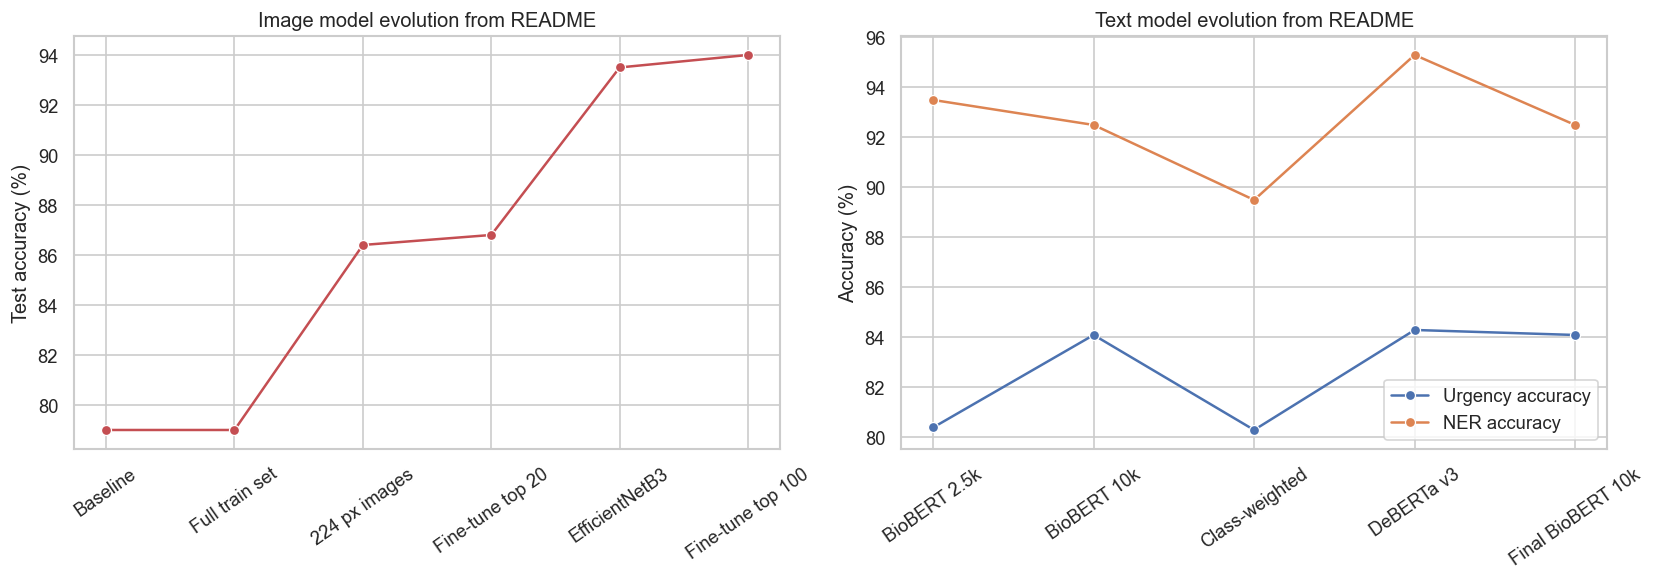

In [12]:
image_evolution = pd.DataFrame(
    [
        {"step": "Baseline", "accuracy": 79.0},
        {"step": "Full train set", "accuracy": 79.0},
        {"step": "224 px images", "accuracy": 86.4},
        {"step": "Fine-tune top 20", "accuracy": 86.8},
        {"step": "EfficientNetB3", "accuracy": 93.5},
        {"step": "Fine-tune top 100", "accuracy": 94.0},
    ]
)

text_evolution = pd.DataFrame(
    [
        {"step": "BioBERT 2.5k", "urgency_accuracy": 80.4, "ner_accuracy": 93.5},
        {"step": "BioBERT 10k", "urgency_accuracy": 84.1, "ner_accuracy": 92.5},
        {"step": "Class-weighted", "urgency_accuracy": 80.3, "ner_accuracy": 89.5},
        {"step": "DeBERTa v3", "urgency_accuracy": 84.3, "ner_accuracy": 95.3},
        {"step": "Final BioBERT 10k", "urgency_accuracy": 84.1, "ner_accuracy": 92.5},
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=image_evolution, x="step", y="accuracy", marker="o", ax=axes[0], color="#C44E52")
axes[0].set_title("Image model evolution from README")
axes[0].set_ylabel("Test accuracy (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.lineplot(
    data=text_evolution,
    x="step",
    y="urgency_accuracy",
    marker="o",
    ax=axes[1],
    label="Urgency accuracy",
)
sns.lineplot(
    data=text_evolution,
    x="step",
    y="ner_accuracy",
    marker="o",
    ax=axes[1],
    label="NER accuracy",
)
axes[1].set_title("Text model evolution from README")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

fig.tight_layout()
fig.savefig(FIG_DIR / "repo_model_evolution.png", bbox_inches="tight", dpi=200)
plt.show()


## Business value, deployment fit, and risk

**Why the system matters**
- It can prioritize incoming veterinary cases before a clinician manually reviews every message.
- The breed branch provides context that can help users trust the system and gives the interface a more complete answer.
- The NER output makes the text model more interpretable because it surfaces symptoms, medications, durations, and other clinically relevant entities.

**Operational fit**
- The final app in `app_gpu.py` decouples the text and image branches, which is cleaner than the older fusion prototype in `app.py`.
- Decoupling the models makes it easier to update the text branch without retraining the image branch.
- The saved checkpoints also make offline evaluation reproducible, which is useful for a final project submission.

**Key risks and limitations**
- The triage text data is synthetic, so there is dataset-shift risk when moving to real clinic messages.
- The fusion prototype in `MultimodalFusionLayer.py` pairs text with random images for demonstration, so it should not be presented as a clinically valid paired multimodal model.
- The urgency outputs are not calibrated probabilities for medical decision making.
- The image model predicts dog breed only; it does not detect injuries, posture, or visible severity directly.
- A real deployment would require human oversight, clinical validation, logging, and privacy review.


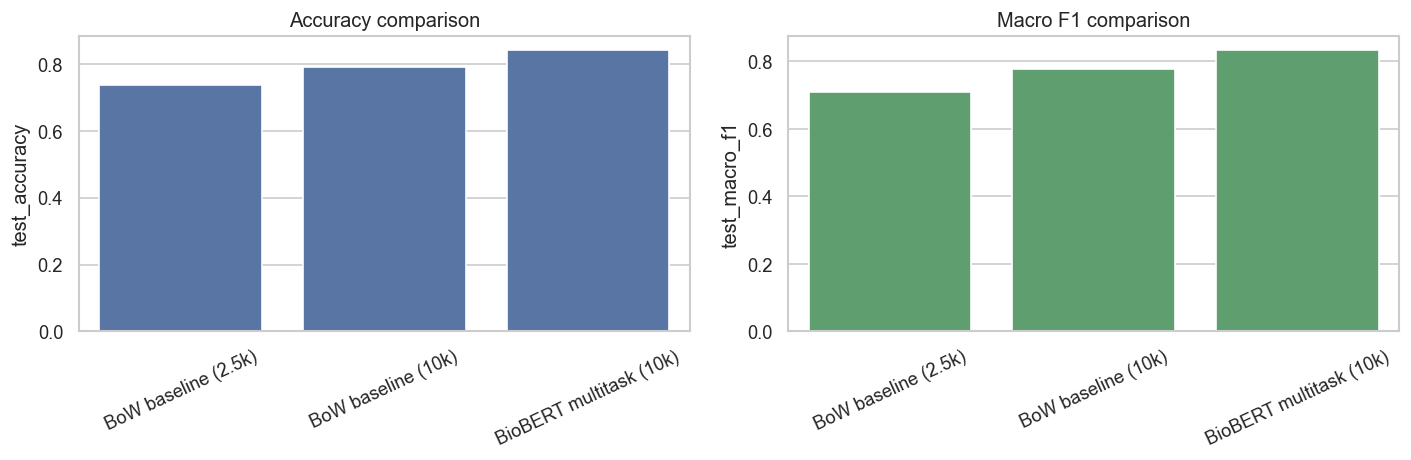

,model,test_accuracy,test_macro_f1
0,BoW baseline (2.5k),0.7360,0.7078
1,BoW baseline (10k),0.7908,0.7772
2,BioBERT multitask (10k),0.8408,0.8326


Saved metrics summary to: /Users/zhucanran/611_final_project_deeplearning-1/output/jupyter-notebook/metrics_summary.json


In [13]:
metrics_summary = {
    "dataset_2500_samples": int(len(triage_2500)),
    "dataset_10k_samples": int(len(triage_10k)),
    "image_train_images": int(image_split_df.loc[image_split_df["split"] == "train", "images"].iloc[0]),
    "image_validation_images": int(image_split_df.loc[image_split_df["split"] == "validation", "images"].iloc[0]),
    "image_test_images": int(image_split_df.loc[image_split_df["split"] == "test", "images"].iloc[0]),
    "bow_2500_test_accuracy": float(baseline_2500["test_accuracy"]),
    "bow_2500_macro_f1": float(baseline_2500["test_macro_f1"]),
    "bow_10k_test_accuracy": float(baseline_10k["test_accuracy"]),
    "bow_10k_macro_f1": float(baseline_10k["test_macro_f1"]),
    "biobert_10k_test_accuracy": float(biobert_summary["test_accuracy"]),
    "biobert_10k_macro_f1": float(biobert_summary["test_macro_f1"]),
    "biobert_10k_weighted_f1": float(biobert_summary["test_weighted_f1"]),
    "biobert_10k_ner_token_accuracy": float(biobert_summary["ner_token_accuracy"]),
    "readme_image_final_accuracy_pct": 94.0,
    "readme_text_final_accuracy_pct": 84.1,
}

comparison_df = pd.DataFrame(
    [
        {
            "model": "BoW baseline (2.5k)",
            "test_accuracy": baseline_2500["test_accuracy"],
            "test_macro_f1": baseline_2500["test_macro_f1"],
        },
        {
            "model": "BoW baseline (10k)",
            "test_accuracy": baseline_10k["test_accuracy"],
            "test_macro_f1": baseline_10k["test_macro_f1"],
        },
        {
            "model": "BioBERT multitask (10k)",
            "test_accuracy": biobert_summary["test_accuracy"],
            "test_macro_f1": biobert_summary["test_macro_f1"],
        },
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=comparison_df, x="model", y="test_accuracy", ax=axes[0], color="#4C72B0")
sns.barplot(data=comparison_df, x="model", y="test_macro_f1", ax=axes[1], color="#55A868")
axes[0].set_title("Accuracy comparison")
axes[1].set_title("Macro F1 comparison")
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "baseline_vs_biobert_metrics.png", bbox_inches="tight", dpi=200)
plt.show()

metrics_path = OUTPUT_DIR / "metrics_summary.json"
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

display(comparison_df.round(4))
print(f"Saved metrics summary to: {metrics_path}")


## References and AI-tool disclosure

Project sources:
- `README.md`
- `embedding.py`
- `text_models_bow_and_embedding.py`
- `MultimodalFusionLayer.py`
- `image_processing_gpu.py`
- `nlp_gpu.py`
- `app.py`
- `app_gpu.py`

External technical references:
- Lee, J., Yoon, W., Kim, S., et al. (2020). BioBERT: a pre-trained biomedical language representation model for biomedical text mining. *Bioinformatics*.
- Tan, M., and Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. *ICML 2019*.
- Hugging Face model identifier used in code: `dmis-lab/biobert-base-cased-v1.2`.

AI-tool disclosure:
- OpenAI Codex (GPT-5-based coding assistant) was used on 2026-03-20 to help scaffold this notebook, organize figures, and draft supporting report text. Every sentence and line of code was manually reviewed.
- The repo README states that synthetic triage data generation used a two-agent Gemini pipeline (writer plus annotator). That disclosure should stay in the written report because it affects data provenance.
